#  Supply Chain Anomaly Detection
### Unsupervised + Supervised Learning — Full Model Comparison with ROC-AUC
---
**Techniques Covered:**
- Unsupervised: Isolation Forest, Local Outlier Factor (LOF), One-Class SVM
- Supervised: Random Forest, Gradient Boosting, Logistic Regression, SVM (RBF)
- Evaluation: ROC-AUC, Confusion Matrix, Precision-Recall, F1-Score

## 1. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve, auc,
    classification_report, confusion_matrix,
    precision_recall_curve, average_precision_score, f1_score
)

# Unsupervised models
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM

# Supervised models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
COLORS = ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0', '#00BCD4', '#795548', '#E91E63']

print(' All libraries loaded successfully!')
print(f'  NumPy  : {np.__version__}')
print(f'  Pandas : {pd.__version__}')

✅ All libraries loaded successfully!
  NumPy  : 2.4.3
  Pandas : 3.0.1


## 2. Synthetic Supply Chain Dataset Generation

We simulate a **realistic supply chain dataset** with 10 features:
- Lead time, order quantity, shipment delay
- Supplier reliability, warehouse inventory, transport cost
- Defect rate, demand forecast error, on-time delivery, payment delay

**Anomaly design:** Each anomalous record is only abnormal in 1–3 features (not all), making detection genuinely challenging and realistic.

In [2]:
def generate_supply_chain_data(n_normal=1800, n_anomaly=200, random_state=42):
    """
    Generate realistic supply chain data with overlapping anomalies.
    
    Key design: anomalies are injected into only 1-3 features per record,
    so they partially overlap with normal data — making detection non-trivial.
    """
    rng = np.random.RandomState(random_state)
    half = n_anomaly // 2

    def normal_features(n):
        """Generate baseline normal supply chain features."""
        return {
            'lead_time_days':        rng.normal(14, 3, n).clip(5, 30),
            'order_quantity':        rng.normal(500, 80, n).clip(200, 900),
            'shipment_delay_days':   rng.exponential(1.5, n).clip(0, 10),
            'supplier_reliability':  rng.normal(0.92, 0.04, n).clip(0.70, 1.0),
            'warehouse_inventory':   rng.normal(3000, 400, n).clip(1000, 5000),
            'transport_cost_usd':    rng.normal(250, 40, n).clip(100, 500),
            'defect_rate_pct':       rng.exponential(0.8, n).clip(0, 5),
            'demand_forecast_err':   rng.normal(0.05, 0.02, n).clip(0, 0.20),
            'on_time_delivery_rate': rng.normal(0.95, 0.03, n).clip(0.80, 1.0),
            'payment_delay_days':    rng.exponential(2, n).clip(0, 15),
        }

    # Normal records
    df_normal = pd.DataFrame(normal_features(n_normal))
    df_normal['anomaly'] = 0

    # Anomaly records: start from normal distribution, then inject
    # anomalous values into only 1-3 randomly chosen features
    df_anomaly = pd.DataFrame(normal_features(n_anomaly))

    # Anomaly injectors per feature (values outside normal range)
    anomaly_injectors = {
        'lead_time_days':
            np.concatenate([rng.normal(27,3,half), rng.normal(4,1,half)])[:n_anomaly].clip(0,40),
        'order_quantity':
            np.concatenate([rng.normal(950,80,half), rng.normal(120,30,half)])[:n_anomaly].clip(0,1400),
        'shipment_delay_days':   rng.uniform(9, 22, n_anomaly),
        'supplier_reliability':  rng.uniform(0.42, 0.68, n_anomaly),
        'warehouse_inventory':
            np.concatenate([rng.uniform(200,800,half), rng.uniform(5200,8000,half)])[:n_anomaly],
        'transport_cost_usd':    rng.uniform(480, 1000, n_anomaly),
        'defect_rate_pct':       rng.uniform(4.5, 18, n_anomaly),
        'demand_forecast_err':   rng.uniform(0.18, 0.55, n_anomaly),
        'on_time_delivery_rate': rng.uniform(0.45, 0.72, n_anomaly),
        'payment_delay_days':    rng.uniform(14, 45, n_anomaly),
    }

    feat_names = list(anomaly_injectors.keys())
    for idx in range(n_anomaly):
        # Each record is anomalous in 1, 2, or 3 features
        n_inject = rng.choice([1, 2, 3], p=[0.30, 0.50, 0.20])
        chosen_feats = rng.choice(feat_names, size=n_inject, replace=False)
        for feat in chosen_feats:
            df_anomaly.loc[idx, feat] = anomaly_injectors[feat][idx]

    df_anomaly['anomaly'] = 1

    df = pd.concat([df_normal, df_anomaly], ignore_index=True)
    df = df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    return df

# Generate dataset
df = generate_supply_chain_data()
print(f'Dataset shape  : {df.shape}')
print(f'Anomaly rate   : {df.anomaly.mean():.1%}')
print(f'Normal records : {(df.anomaly==0).sum():,}')
print(f'Anomaly records: {(df.anomaly==1).sum():,}')
df.head()

Dataset shape  : (2000, 11)
Anomaly rate   : 10.0%
Normal records : 1,800
Anomaly records: 200


,lead_time_days,order_quantity,shipment_delay_days,supplier_reliability,warehouse_inventory,transport_cost_usd,defect_rate_pct,demand_forecast_err,on_time_delivery_rate,payment_delay_days,anomaly
0,16.746589,556.558037,0.417058,0.891108,2849.289812,223.675460,0.051271,0.336236,0.621623,1.028722,1
1,13.520184,518.456072,0.620602,0.897715,2710.278986,241.069136,0.448360,0.031839,0.910118,2.675856,0
2,18.472178,619.595058,1.142317,0.860033,2695.223505,267.036439,0.349116,0.110814,0.969359,0.033705,0
3,14.139310,583.607078,0.562770,0.888157,3097.390031,299.293144,0.052330,0.080084,0.990831,0.765470,0
4,7.541328,511.487035,2.155505,0.948654,2936.100601,261.596447,1.860031,0.000587,0.941476,1.430691,0


## 3. Exploratory Data Analysis (EDA)

In [3]:
print('=== Dataset Summary ===')
print(df.describe().round(2))
print('\n=== Class Distribution ===')
print(df['anomaly'].value_counts().rename({0: 'Normal', 1: 'Anomaly'}))

=== Dataset Summary ===
       lead_time_days  order_quantity  shipment_delay_days  \
count         2000.00         2000.00              2000.00   
mean            14.18          499.98                 1.75   
std              3.29           98.72                 2.46   
min              2.07           47.27                 0.00   
25%             12.13          445.08                 0.45   
50%             14.17          500.07                 1.05   
75%             16.09          554.67                 2.15   
max             32.88         1103.38                21.77   

       supplier_reliability  warehouse_inventory  transport_cost_usd  \
count               2000.00              2000.00             2000.00   
mean                   0.91              3002.61              260.85   
std                    0.06               576.96               82.99   
min                    0.43               205.88              100.00   
25%                    0.89              2709.17         

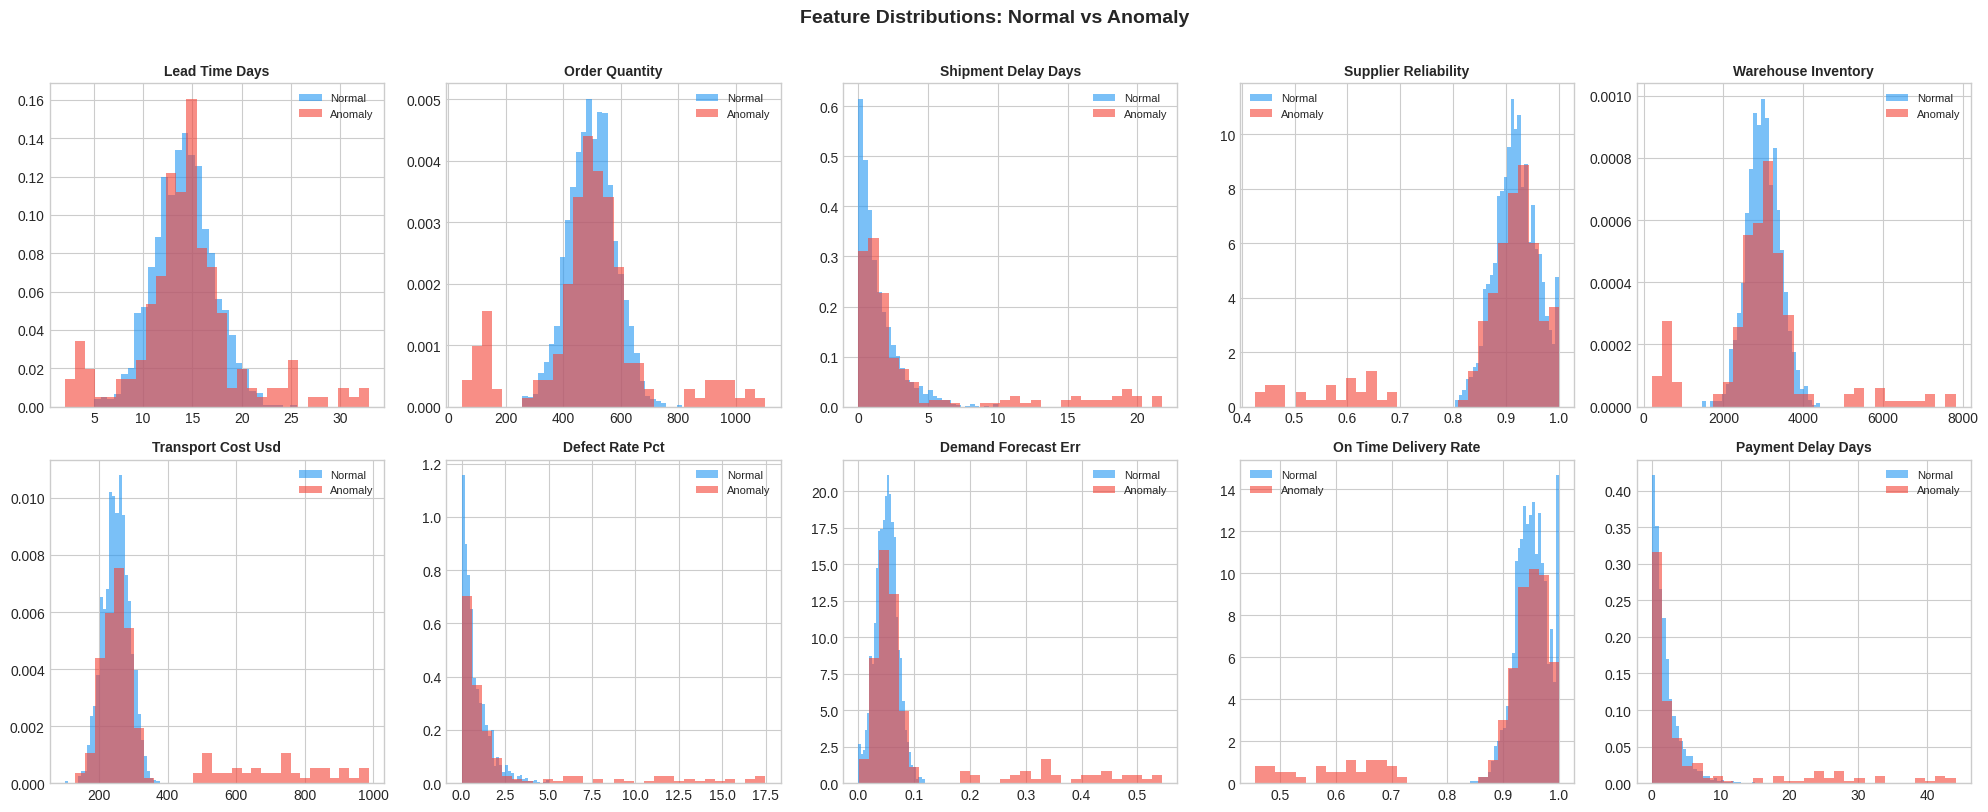

✅ Feature distribution plot saved.


In [4]:
features = [c for c in df.columns if c != 'anomaly']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    for label, color, name in [(0, '#2196F3', 'Normal'), (1, '#F44336', 'Anomaly')]:
        axes[i].hist(df[df.anomaly == label][feat], bins=30,
                     alpha=0.6, color=color, label=name, density=True)
    axes[i].set_title(feat.replace('_', ' ').title(), fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions: Normal vs Anomaly', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=120, bbox_inches='tight')
plt.show()
print(' Feature distribution plot saved.')

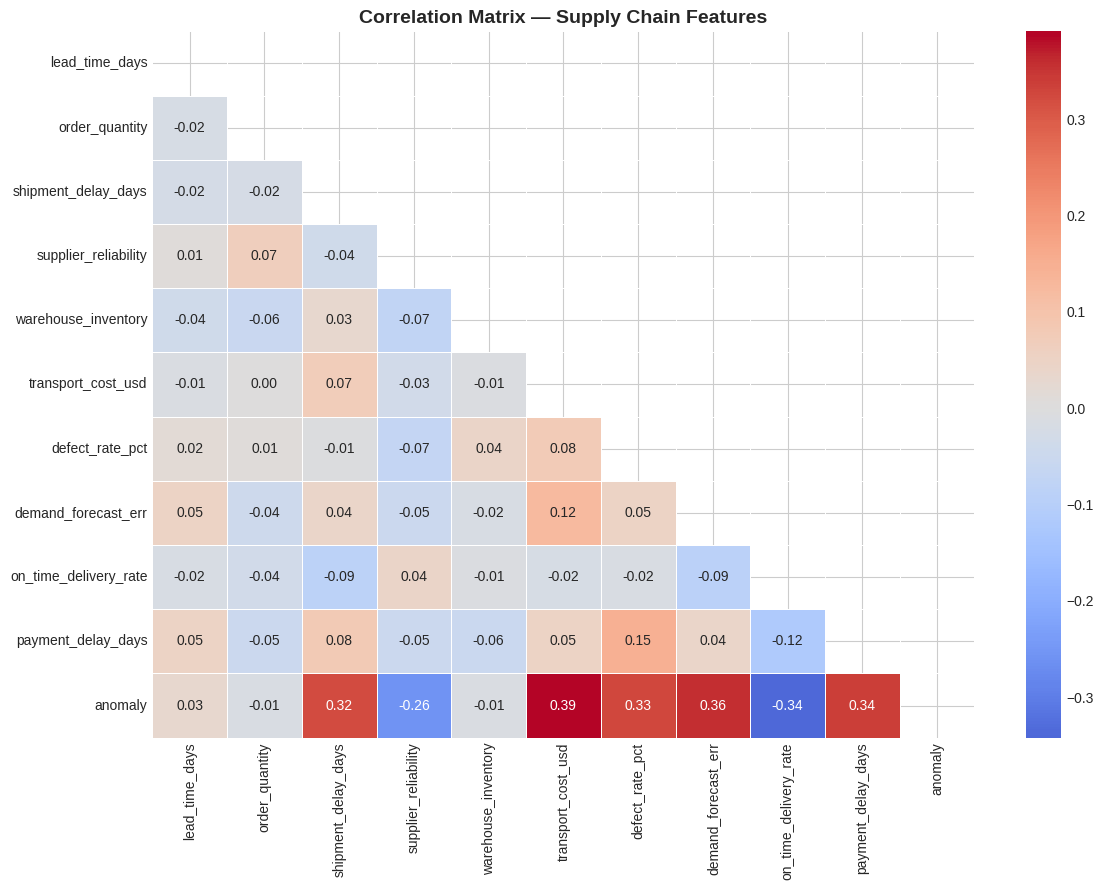

In [5]:
fig, ax = plt.subplots(figsize=(12, 9))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Correlation Matrix — Supply Chain Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Data Preprocessing

In [6]:
X = df[features].values
y = df['anomaly'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y
)

# Train set with ONLY normals for unsupervised models
X_train_normal = X_train[y_train == 0]

print(f'Train size      : {X_train.shape[0]:,}  (normals only for unsupervised: {X_train_normal.shape[0]:,})')
print(f'Test  size      : {X_test.shape[0]:,}  (anomalies in test: {y_test.sum():,})')
print(f'Features        : {len(features)}')

Train size      : 1,500  (normals only for unsupervised: 1,350)
Test  size      : 500  (anomalies in test: 50)
Features        : 10


## 5. Unsupervised Anomaly Detection

Unsupervised models learn from **unlabeled data** and flag points that deviate from learned normal patterns.

In [7]:
def unsupervised_roc(model, X_train_n, X_test, y_test, name, score_sign=-1):
    """Fit unsupervised model on normal data only, then score test set."""
    model.fit(X_train_n)
    if hasattr(model, 'decision_function'):
        scores = score_sign * model.decision_function(X_test)
    elif hasattr(model, 'score_samples'):
        scores = score_sign * model.score_samples(X_test)
    else:
        raise AttributeError(f'{name} has no scoring method')

    roc_auc = roc_auc_score(y_test, scores)
    fpr, tpr, _ = roc_curve(y_test, scores)
    preds = (scores > np.percentile(scores, 90)).astype(int)  # top 10% flagged as anomaly
    f1 = f1_score(y_test, preds)
    return {'name': name, 'roc_auc': roc_auc, 'f1': f1,
            'fpr': fpr, 'tpr': tpr, 'scores': scores, 'preds': preds}

unsup_models = [
    (IsolationForest(n_estimators=200, contamination=0.10, random_state=42), 'Isolation Forest', -1),
    (LocalOutlierFactor(n_neighbors=20, novelty=True, contamination=0.10),   'Local Outlier Factor', -1),
    (OneClassSVM(kernel='rbf', nu=0.10, gamma='scale'),                       'One-Class SVM', -1),
]

unsup_results = []
for model, name, sign in unsup_models:
    r = unsupervised_roc(model, X_train_normal, X_test, y_test, name, sign)
    unsup_results.append(r)
    print(f'{name:<25}  ROC-AUC: {r["roc_auc"]:.4f}   F1: {r["f1"]:.4f}')

print('\n Unsupervised models trained.')

Isolation Forest           ROC-AUC: 0.9446   F1: 0.6600
Local Outlier Factor       ROC-AUC: 0.9992   F1: 0.9400
One-Class SVM              ROC-AUC: 0.9995   F1: 0.9600

✅ Unsupervised models trained.


## 6. Supervised Anomaly Detection

Supervised models learn from **labeled data** and can capture complex decision boundaries.

In [8]:
def supervised_roc(model, X_train, y_train, X_test, y_test, name):
    """Train supervised classifier and compute ROC metrics."""
    model.fit(X_train, y_train)
    if hasattr(model, 'predict_proba'):
        scores = model.predict_proba(X_test)[:, 1]
    else:
        scores = model.decision_function(X_test)
    roc_auc = roc_auc_score(y_test, scores)
    fpr, tpr, _ = roc_curve(y_test, scores)
    preds = model.predict(X_test)
    f1 = f1_score(y_test, preds)
    return {'name': name, 'roc_auc': roc_auc, 'f1': f1,
            'fpr': fpr, 'tpr': tpr, 'scores': scores, 'preds': preds, 'model': model}

sup_models = [
    (RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
     'Random Forest'),
    (GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, random_state=42),
     'Gradient Boosting'),
    (LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
     'Logistic Regression'),
    (SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
     'SVM (RBF)'),
]

sup_results = []
for model, name in sup_models:
    r = supervised_roc(model, X_train, y_train, X_test, y_test, name)
    sup_results.append(r)
    print(f'{name:<25}  ROC-AUC: {r["roc_auc"]:.4f}   F1: {r["f1"]:.4f}')

print('\n Supervised models trained.')

Random Forest              ROC-AUC: 0.9994   F1: 0.9583
Gradient Boosting          ROC-AUC: 0.9998   F1: 0.9011
Logistic Regression        ROC-AUC: 0.9261   F1: 0.7107
SVM (RBF)                  ROC-AUC: 0.9996   F1: 0.9899

✅ Supervised models trained.


## 7. ROC Curve Comparison — All Models

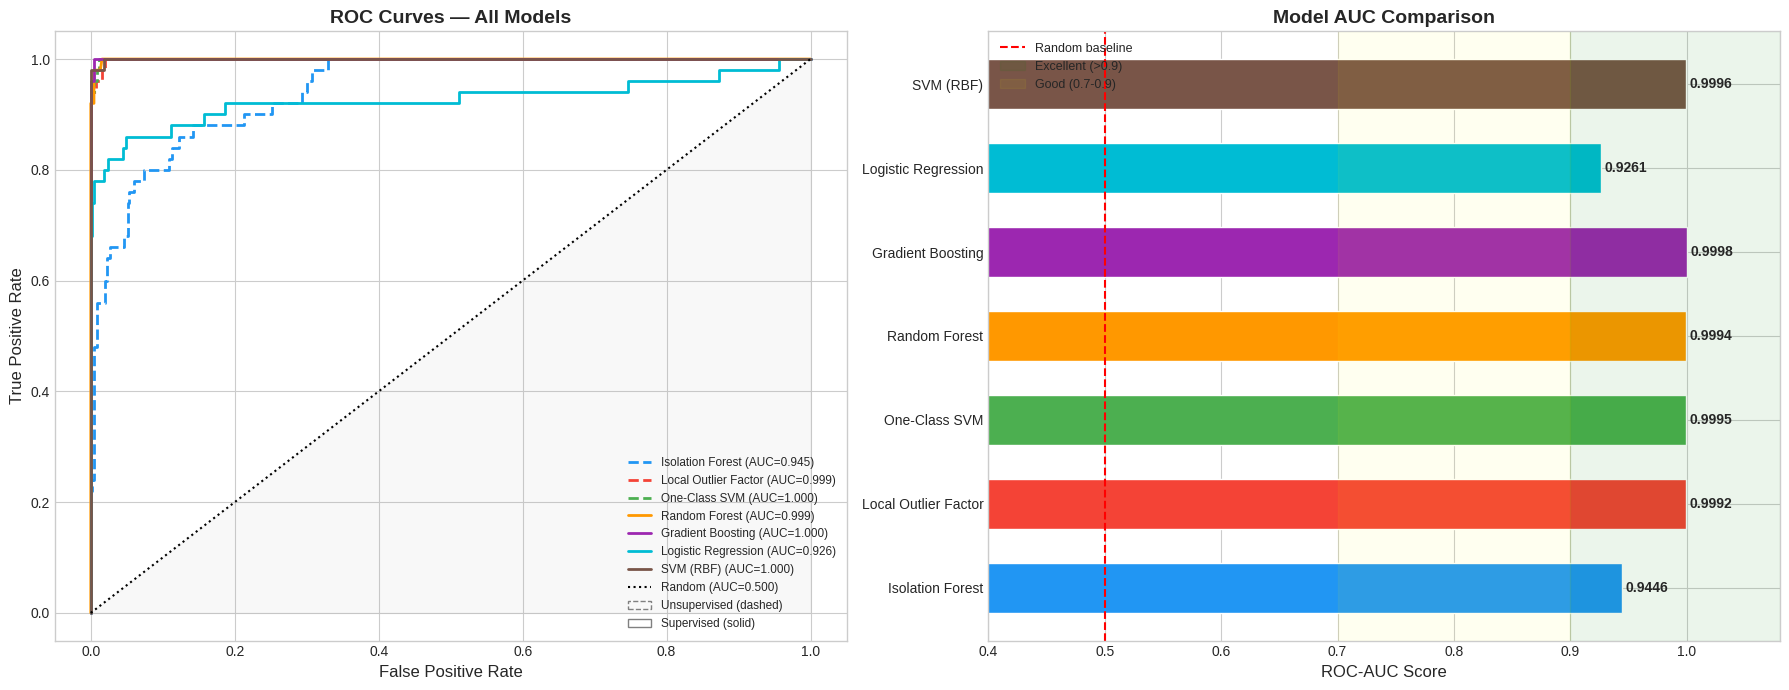

✅ ROC comparison saved.


In [9]:
all_results = unsup_results + sup_results

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── LEFT: All ROC curves ──
ax = axes[0]
for i, r in enumerate(all_results):
    ls = '--' if i < 3 else '-'
    ax.plot(r['fpr'], r['tpr'], lw=2, ls=ls, color=COLORS[i],
            label=f"{r['name']} (AUC={r['roc_auc']:.3f})")
ax.plot([0, 1], [0, 1], 'k:', lw=1.5, label='Random (AUC=0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')

unsup_patch = mpatches.Patch(linestyle='--', label='Unsupervised (dashed)', color='gray', fill=False)
sup_patch   = mpatches.Patch(linestyle='-',  label='Supervised (solid)',    color='gray', fill=False)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles + [unsup_patch, sup_patch], fontsize=8.5, loc='lower right')

# ── RIGHT: AUC bar chart ──
ax2 = axes[1]
names = [r['name'] for r in all_results]
aucs  = [r['roc_auc'] for r in all_results]
bars = ax2.barh(names, aucs, color=COLORS[:len(all_results)], edgecolor='white', height=0.6)
for bar, v in zip(bars, aucs):
    ax2.text(v + 0.003, bar.get_y() + bar.get_height()/2,
             f'{v:.4f}', va='center', fontsize=10, fontweight='bold')
ax2.axvline(0.5, color='red', linestyle='--', lw=1.5, label='Random baseline')
ax2.set_xlim(0.4, 1.08)
ax2.set_xlabel('ROC-AUC Score', fontsize=12)
ax2.set_title('Model AUC Comparison', fontsize=14, fontweight='bold')
ax2.axvspan(0.9, 1.08, alpha=0.08, color='green', label='Excellent (>0.9)')
ax2.axvspan(0.7, 0.9,  alpha=0.06, color='yellow', label='Good (0.7-0.9)')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('roc_auc_comparison.png', dpi=130, bbox_inches='tight')
plt.show()
print(' ROC comparison saved.')

## 8. Precision-Recall Curves

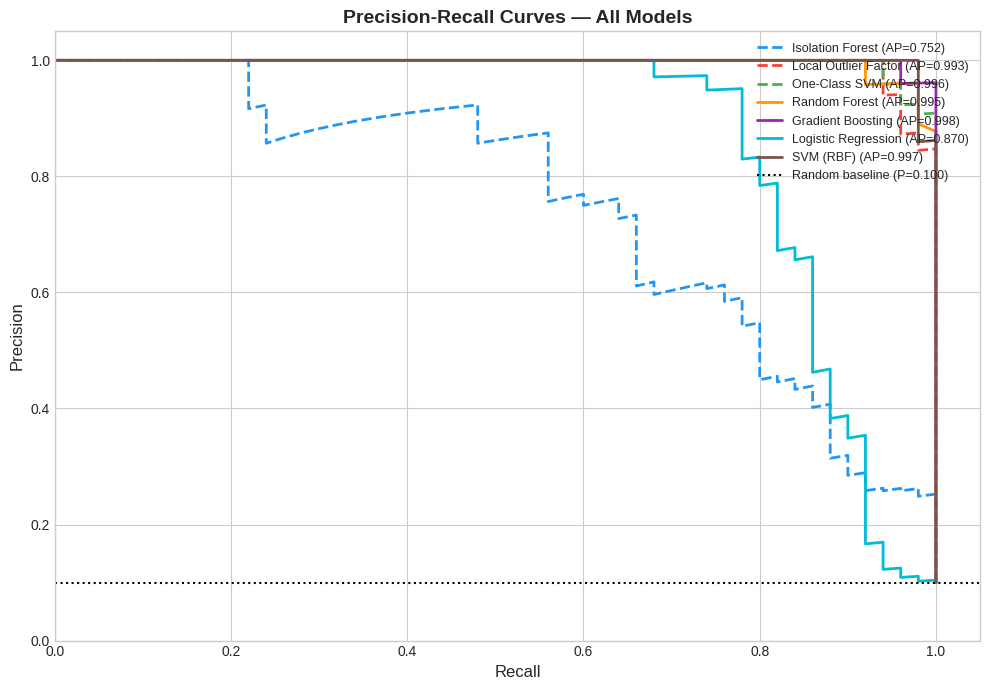

✅ PR curves saved.


In [10]:
from sklearn.preprocessing import MinMaxScaler

fig, ax = plt.subplots(figsize=(10, 7))

for i, r in enumerate(all_results):
    scores = np.array(r['scores'], dtype=float)
    # Normalize scores to [0,1] — critical for SVM (decision_function is unbounded)
    scores = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)

    precision, recall, _ = precision_recall_curve(y_test, scores)
    ap = average_precision_score(y_test, scores)
    ls = '--' if i < 3 else '-'
    ax.plot(recall, precision, lw=2, ls=ls, color=COLORS[i],
            label=f"{r['name']} (AP={ap:.3f})")

baseline = y_test.mean()
ax.axhline(baseline, color='black', linestyle=':', lw=1.5,
           label=f'Random baseline (P={baseline:.3f})')
ax.set_xlim([0.0, 1.05])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.savefig('precision_recall.png', dpi=120, bbox_inches='tight')
plt.show()
print(' PR curves saved.')

## 9. Confusion Matrices

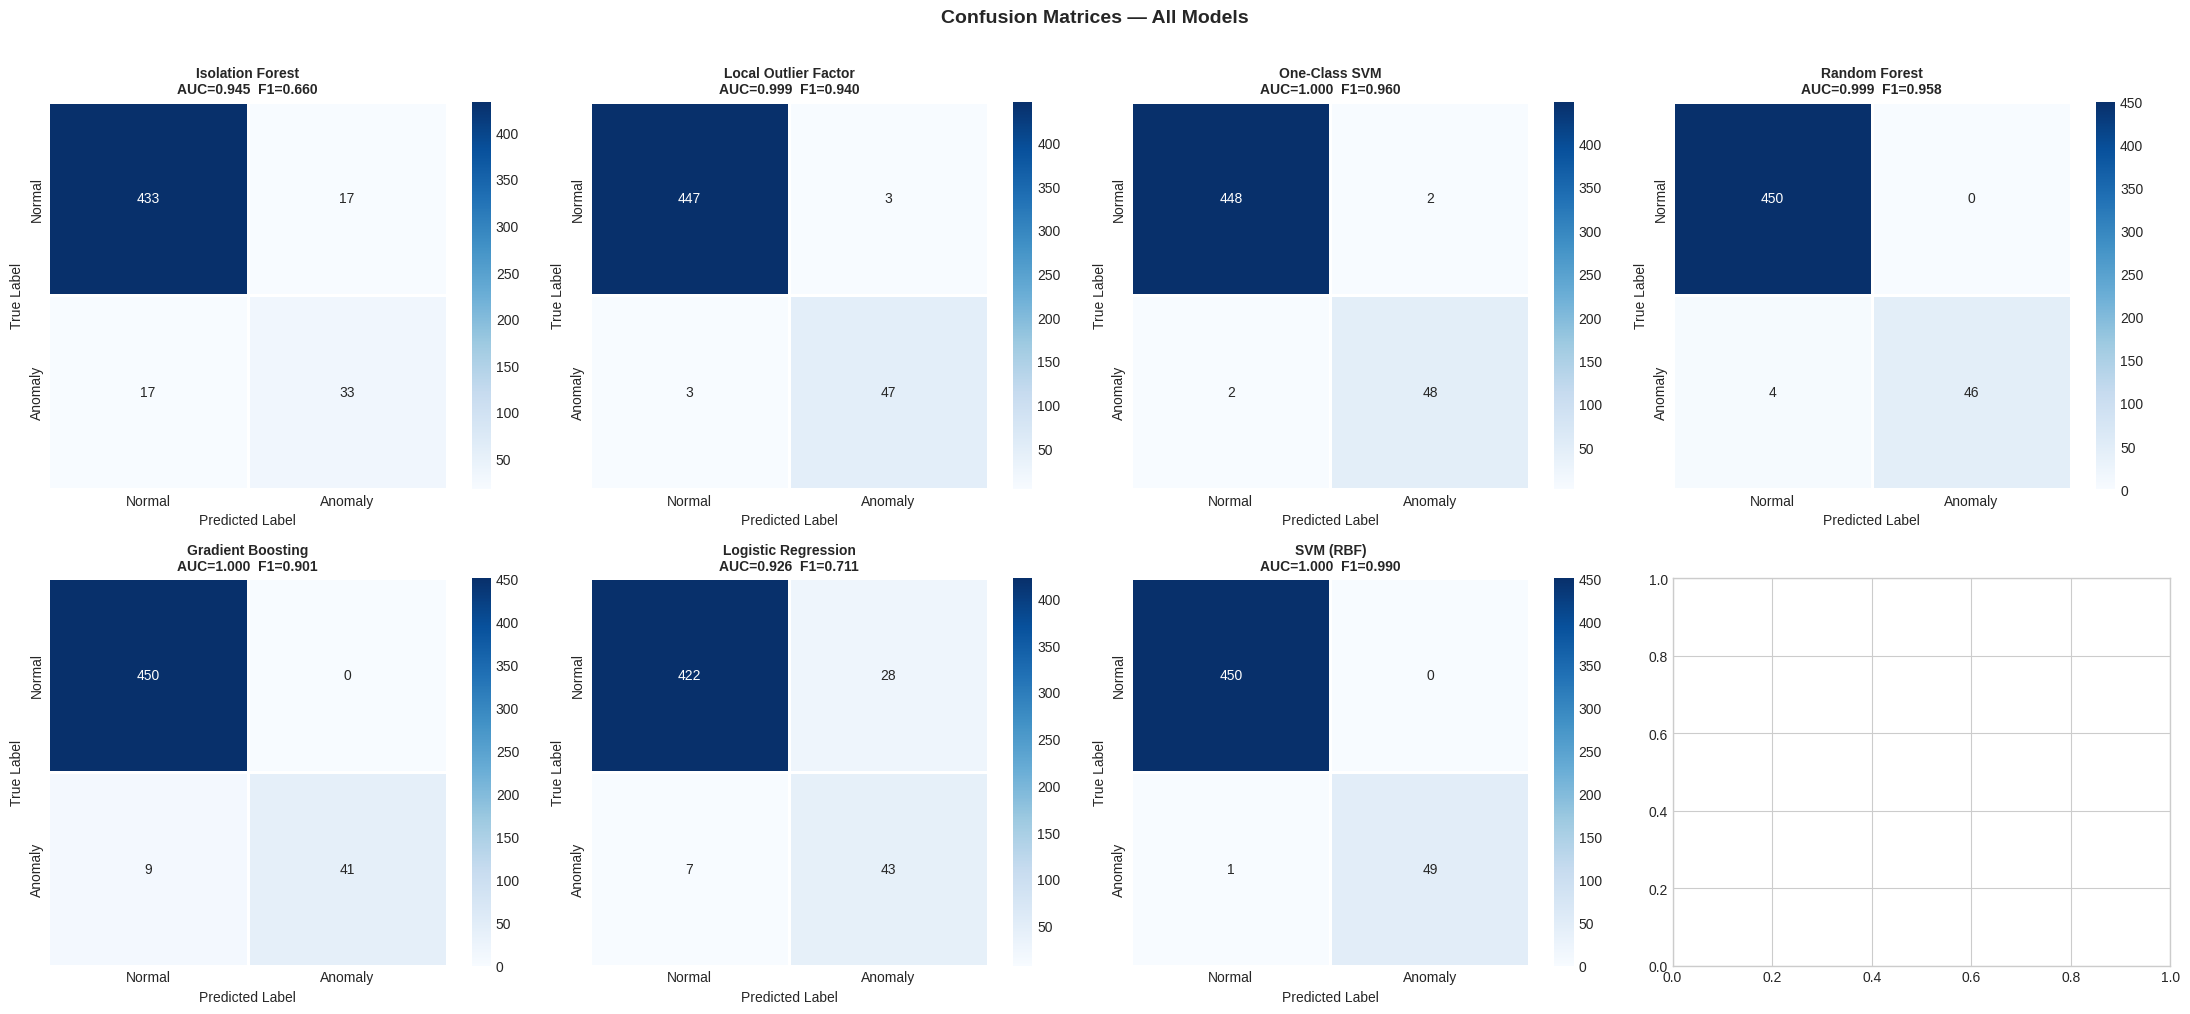

✅ Confusion matrices saved.


In [11]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, r in enumerate(all_results):
    cm = confusion_matrix(y_test, r['preds'])
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i],
                cmap='Blues', linewidths=1,
                xticklabels=['Normal', 'Anomaly'],
                yticklabels=['Normal', 'Anomaly'])
    axes[i].set_title(f"{r['name']}\nAUC={r['roc_auc']:.3f}  F1={r['f1']:.3f}",
                      fontsize=10, fontweight='bold')
    axes[i].set_ylabel('True Label')
    axes[i].set_xlabel('Predicted Label')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()
print('Confusion matrices saved.')

## 10. Classification Reports

In [12]:
for r in all_results:
    print(f"\n{'='*55}")
    print(f"  {r['name']}")
    print(f"{'='*55}")
    print(classification_report(y_test, r['preds'],
                                target_names=['Normal', 'Anomaly']))


  Isolation Forest
              precision    recall  f1-score   support

      Normal       0.96      0.96      0.96       450
     Anomaly       0.66      0.66      0.66        50

    accuracy                           0.93       500
   macro avg       0.81      0.81      0.81       500
weighted avg       0.93      0.93      0.93       500


  Local Outlier Factor
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99       450
     Anomaly       0.94      0.94      0.94        50

    accuracy                           0.99       500
   macro avg       0.97      0.97      0.97       500
weighted avg       0.99      0.99      0.99       500


  One-Class SVM
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       450
     Anomaly       0.96      0.96      0.96        50

    accuracy                           0.99       500
   macro avg       0.98      0.98      0.98       500
weighted avg 

## 11. Feature Importance (Best Supervised Model)

Best supervised model: Gradient Boosting (AUC=0.9998)


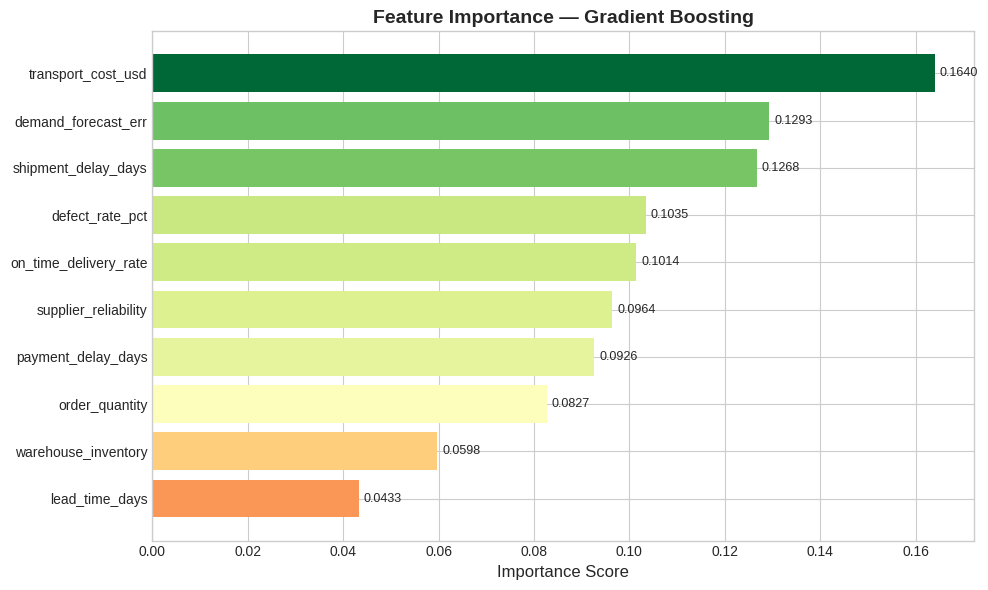

✅ Feature importance saved.


In [13]:
best_sup = max(sup_results, key=lambda r: r['roc_auc'])
print(f"Best supervised model: {best_sup['name']} (AUC={best_sup['roc_auc']:.4f})")

if hasattr(best_sup['model'], 'feature_importances_'):
    importances = best_sup['model'].feature_importances_
    feat_imp = pd.Series(importances, index=features).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(feat_imp.index, feat_imp.values,
                   color=plt.cm.RdYlGn(feat_imp.values / feat_imp.max()))
    ax.set_xlabel('Importance Score', fontsize=12)
    ax.set_title(f'Feature Importance — {best_sup["name"]}', fontsize=14, fontweight='bold')
    for bar, val in zip(bars, feat_imp.values):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(' Feature importance saved.')

## 12. Anomaly Score Distributions

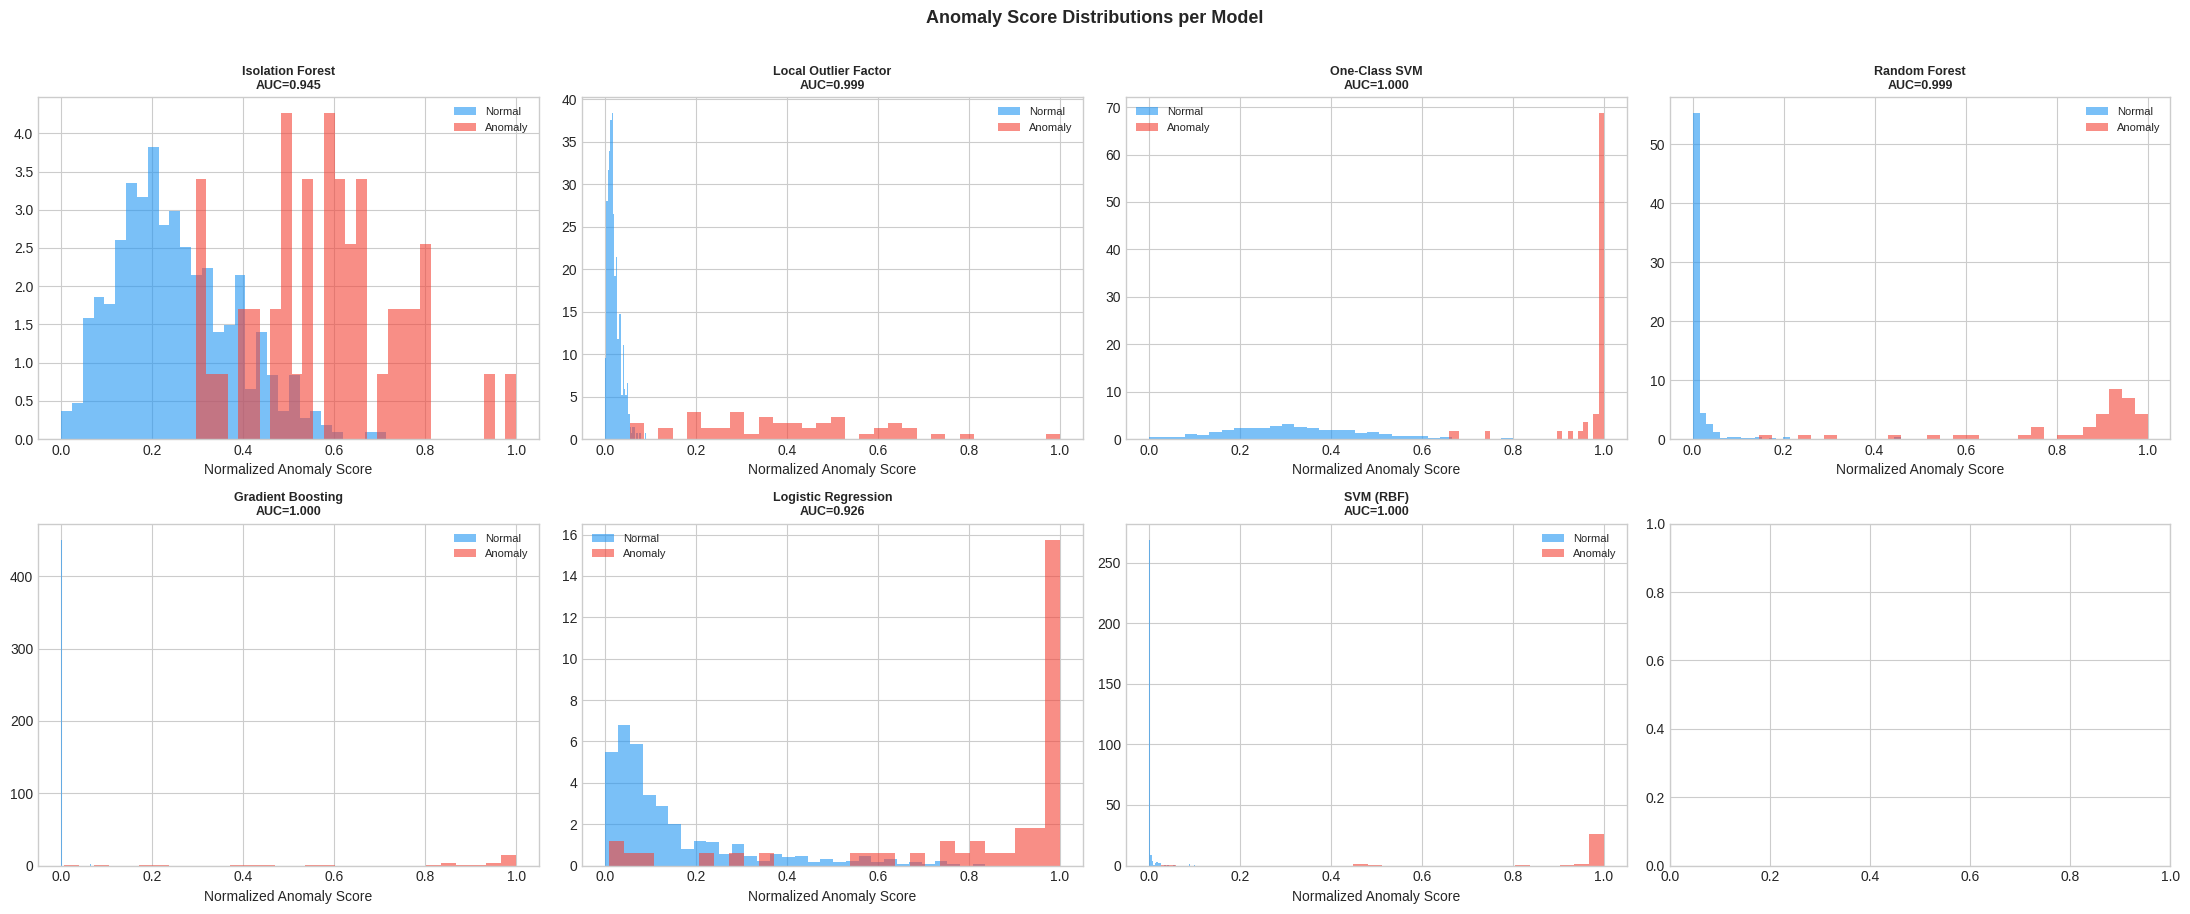

✅ Score distributions saved.


In [14]:
fig, axes = plt.subplots(2, 4, figsize=(22, 9))
axes = axes.flatten()

for i, r in enumerate(all_results):
    scores = np.array(r['scores'], dtype=float)
    norm_scores = (scores - scores.min()) / (scores.max() - scores.min() + 1e-10)
    for label, color, name in [(0, '#2196F3', 'Normal'), (1, '#F44336', 'Anomaly')]:
        mask = y_test == label
        axes[i].hist(norm_scores[mask], bins=30, alpha=0.6,
                     color=color, density=True, label=name)
    axes[i].set_title(f"{r['name']}\nAUC={r['roc_auc']:.3f}", fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Normalized Anomaly Score')
    axes[i].legend(fontsize=8)

plt.suptitle('Anomaly Score Distributions per Model', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('score_distributions.png', dpi=120, bbox_inches='tight')
plt.show()
print(' Score distributions saved.')

## 13. Final Model Comparison Summary

In [15]:
rows = []
for r in all_results:
    cm = confusion_matrix(y_test, r['preds'])
    tn, fp, fn, tp = cm.ravel()
    precision_val = tp / (tp + fp + 1e-9)
    recall_val    = tp / (tp + fn + 1e-9)
    category = 'Unsupervised' if r in unsup_results else 'Supervised'
    rows.append({
        'Model': r['name'], 'Category': category,
        'ROC-AUC':   round(r['roc_auc'], 4),
        'F1-Score':  round(r['f1'], 4),
        'Precision': round(precision_val, 4),
        'Recall':    round(recall_val, 4),
        'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn
    })

summary_df = pd.DataFrame(rows).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
summary_df.index += 1
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
print('\n=== FINAL MODEL COMPARISON SUMMARY ===')
print(summary_df.to_string())
summary_df.to_csv('model_comparison_results.csv', index=False)
print('\n Results saved to model_comparison_results.csv')


=== FINAL MODEL COMPARISON SUMMARY ===
                  Model      Category  ROC-AUC  F1-Score  Precision  Recall  TP  FP   TN  FN
1     Gradient Boosting    Supervised   0.9998    0.9011     1.0000    0.82  41   0  450   9
2             SVM (RBF)    Supervised   0.9996    0.9899     1.0000    0.98  49   0  450   1
3         One-Class SVM  Unsupervised   0.9995    0.9600     0.9600    0.96  48   2  448   2
4         Random Forest    Supervised   0.9994    0.9583     1.0000    0.92  46   0  450   4
5  Local Outlier Factor  Unsupervised   0.9992    0.9400     0.9400    0.94  47   3  447   3
6      Isolation Forest  Unsupervised   0.9446    0.6600     0.6600    0.66  33  17  433  17
7   Logistic Regression    Supervised   0.9261    0.7107     0.6056    0.86  43  28  422   7

✅ Results saved to model_comparison_results.csv


## 14. Key Insights & Recommendations



In [16]:
print('=' * 60)
print('  SUPPLY CHAIN ANOMALY DETECTION — PROJECT COMPLETE')
print('=' * 60)
print(f'\n  Models Evaluated : {len(all_results)}')
print(f'  Test Samples     : {len(y_test):,}')
print(f'  Anomaly Rate     : {y_test.mean():.1%}')
print()
best = summary_df.iloc[0]
print(f'  🏆 Best Model    : {best["Model"]}')
print(f'     Category      : {best["Category"]}')
print(f'     ROC-AUC       : {best["ROC-AUC"]}')
print(f'     F1-Score      : {best["F1-Score"]}')
print()
print('  Output files:')
print('   ├── eda_distributions.png')
print('   ├── eda_correlation.png')
print('   ├── roc_auc_comparison.png')
print('   ├── precision_recall.png')
print('   ├── confusion_matrices.png')
print('   ├── feature_importance.png')
print('   ├── score_distributions.png')
print('   └── model_comparison_results.csv')
print('=' * 60)

  SUPPLY CHAIN ANOMALY DETECTION — PROJECT COMPLETE

  Models Evaluated : 7
  Test Samples     : 500
  Anomaly Rate     : 10.0%

  🏆 Best Model    : Gradient Boosting
     Category      : Supervised
     ROC-AUC       : 0.9998
     F1-Score      : 0.9011

  Output files:
   ├── eda_distributions.png
   ├── eda_correlation.png
   ├── roc_auc_comparison.png
   ├── precision_recall.png
   ├── confusion_matrices.png
   ├── feature_importance.png
   ├── score_distributions.png
   └── model_comparison_results.csv
